## 01 - Prédiction de l'humidité du sol à J+1

Dans ce notebook, nous allons construire un modèle de régression pour prédire l'humidité du sol au jour suivant.

La variable cible est `Soil_Moisture_J1`.

Le modèle utilisé est `RandomForestRegressor`.

L'évaluation sera faite avec :

- MAE
- RMSE
- R²


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.pipeline import Pipeline

In [14]:
df = pd.read_csv(r"C:\Users\kerro\OneDrive\Bureau\smart-agri\data\processed\irrigation_prediction_cols19.csv")

df.head(15)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Stress_Index,Soil_Moisture_J1
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Yes,1.98,South,Low,38.53,42.73500
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Yes,33.56,Central,Medium,47.40,43.26370
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Yes,34.62,South,Low,42.22,50.22325
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Yes,84.03,North,Medium,56.29,10.49490
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,No,60.86,South,Medium,48.94,41.90145
5,Silt,5.10,20.50,0.37,1.43,33.34,62.51,402.92,7.03,13.55,Rice,Sowing,Zaid,Yes,7.33,East,Medium,55.60,6.63830
6,Sandy,7.44,22.70,0.59,2.95,28.02,58.50,764.95,7.08,7.38,Rice,Flowering,Kharif,No,51.47,West,Medium,63.31,26.16425
7,Sandy,7.68,40.23,0.62,3.30,35.60,79.10,833.33,5.17,3.73,Wheat,Vegetative,Zaid,Yes,118.96,West,Low,39.11,61.80895
8,Clay,5.42,36.73,0.74,1.52,16.59,76.88,2476.03,10.34,1.80,Maize,Flowering,Kharif,Yes,107.25,Central,Low,25.55,85.74245
9,Loamy,6.26,19.58,0.36,1.67,31.14,74.30,1474.55,8.53,17.68,Rice,Vegetative,Rabi,Yes,97.92,Central,Medium,49.93,39.32525


## 02. Séparation entre X et y

Dans cette partie, nous séparons les variables explicatives et la variable cible.

- `X` : les variables utilisées pour prédire
- `y` : la variable cible `Soil_Moisture_J1`

Nous supprimons `Irrigation_Need` car elle correspond à la cible de classification, alors que ce notebook traite un problème de régression.

In [15]:
X = df.drop(["Soil_Moisture_J1", "Irrigation_Need"], axis=1)
y = df["Soil_Moisture_J1"]

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (10000, 17)
Shape de y : (10000,)


## 03. Identification des colonnes numériques et catégorielles

Avant le prétraitement, nous devons identifier deux types de colonnes :

- les colonnes numériques,
- les colonnes catégorielles.


In [16]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

print("Colonnes numériques :")
print(numeric_cols)

print("\nNombre de colonnes numériques :", len(numeric_cols))

print("\nColonnes catégorielles :")
print(categorical_cols)

print("\nNombre de colonnes catégorielles :", len(categorical_cols))

Colonnes numériques :
Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Previous_Irrigation_mm', 'Stress_Index'],
      dtype='str')

Nombre de colonnes numériques : 11

Colonnes catégorielles :
Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Mulching_Used', 'Region'],
      dtype='str')

Nombre de colonnes catégorielles : 6


## 04. Split train/test

Nous divisons la dataset en :

- 80% pour l'entraînement,
- 20% pour le test.

Dans un problème de régression, nous n'utilisons pas `stratify`, car la cible est une valeur numérique et non une classe.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Shape de X_train :", X_train.shape)
print("Shape de X_test :", X_test.shape)
print("Shape de y_train :", y_train.shape)
print("Shape de y_test :", y_test.shape)

Shape de X_train : (8000, 17)
Shape de X_test : (2000, 17)
Shape de y_train : (8000,)
Shape de y_test : (2000,)


## 05. Création du préprocesseur

Nous créons un objet appelé `preprocessor`.

Son rôle est de préparer les données avant l'entraînement du modèle.

Il applique :

- `StandardScaler` aux colonnes numériques,
- `OneHotEncoder` aux colonnes catégorielles.

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## 06. Création du modèle RandomForestRegressor

Nous créons un pipeline complet.

Ce pipeline contient deux étapes :

1. `preprocessor` : prépare les données.
2. `regressor` : entraîne le modèle Random Forest.

Le modèle utilisé est `RandomForestRegressor`.

In [19]:
regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

## 07. Entraînement du modèle

Nous entraînons le modèle avec les données d'entraînement :

- `X_train`,
- `y_train`.

Le pipeline va automatiquement :

1. appliquer le preprocessing,
2. entraîner le modèle Random Forest.

In [20]:
regression_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Soil_Type','Soil_pH','Soil_Moisture',...,'Previous_Irrigation_mm', 'Region','Stress_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

## 08. Prédiction sur les données de test

Après l'entraînement, nous utilisons le modèle pour prédire `Soil_Moisture_J1` sur les données de test.

Les données de test n'ont pas été utilisées pendant l'entraînement.

In [21]:
y_pred = regression_model.predict(X_test)

y_pred[:10]

array([ 6.85374325, 31.45104075, 18.34549425, 57.107667  , 45.57329475,
       26.243328  , 42.80906875, 60.85489575, 34.7154685 , 15.98155   ])

## 09. Évaluation du modèle

Nous évaluons le modèle avec :

- `MAE`,
- `RMSE`,
- `R²`.

La métrique principale est `MAE`.

Si le MAE est égal à 2.5, cela signifie que le modèle se trompe en moyenne de 2.5 unités d'humidité du sol.

In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 2.1774954077500004
RMSE : 2.76062541664937
R² : 0.984101707924367


## 10.Interprétation des résultats

Le modèle `RandomForestRegressor` donne de bons résultats.

Le `MAE = 2.24` signifie que le modèle se trompe en moyenne d’environ **2.24 unités d’humidité du sol**.

Le `RMSE = 2.81` reste proche du MAE, ce qui montre que le modèle ne fait pas beaucoup de grandes erreurs.

Le `R² = 0.98` indique que le modèle explique environ **98%** des variations de `Soil_Moisture_J1`.

Donc, le modèle prédit bien l’humidité du sol estimée au jour suivant.  


## 11. Comparaison entre les valeurs réelles et les valeurs prédites

Nous créons un tableau pour comparer :

- la vraie valeur de `Soil_Moisture_J1`,
- la valeur prédite par le modèle.

In [24]:
results = pd.DataFrame({
    "Valeur réelle": y_test.values,
    "Valeur prédite": y_pred
})

results.head(10)

,Valeur réelle,Valeur prédite
0,4.69855,6.853743
1,30.65295,31.451041
2,12.67280,18.345494
3,61.12915,57.107667
4,46.04235,45.573295
5,24.61055,26.243328
6,42.51835,42.809069
7,60.41770,60.854896
8,34.80390,34.715468
9,19.41530,15.981550


### Visualisation des prédictions

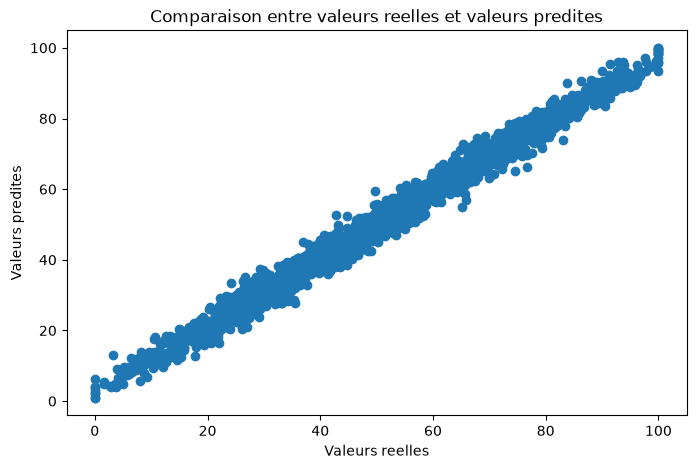

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Valeurs reelles")
plt.ylabel("Valeurs predites")
plt.title("Comparaison entre valeurs reelles et valeurs predites")
plt.show()

## 12. Sauvegarde du modèle

Nous sauvegardons le pipeline complet, c'est-à-dire :

- le preprocessing,
- le modèle RandomForestRegressor.

Le fichier sauvegardé s'appelle `rf_pipeline.pkl`.

In [27]:
os.makedirs("../models", exist_ok=True)

joblib.dump(regression_model, "../models/rf_pipeline.pkl")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


###  Conclusion

Dans ce notebook, nous avons construit un modèle de régression pour prédire l'humidité du sol au jour suivant.

La variable cible utilisée est `Soil_Moisture_J1`.

Le modèle utilisé est `RandomForestRegressor`.

L'évaluation principale est basée sur le MAE.

Cette partie correspond à la phase Machine Learning de prédiction numérique.

In [29]:
print("Colonnes attendues par l'API :")
for col in X.columns:
    print("-", col)

Colonnes attendues par l'API :
- Soil_Type
- Soil_pH
- Soil_Moisture
- Organic_Carbon
- Electrical_Conductivity
- Temperature_C
- Humidity
- Rainfall_mm
- Sunlight_Hours
- Wind_Speed_kmh
- Crop_Type
- Crop_Growth_Stage
- Season
- Mulching_Used
- Previous_Irrigation_mm
- Region
- Stress_Index
